<a href="https://colab.research.google.com/github/iprachuk/global_sales_insights/blob/main/global_sales_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**All imported files and files linked to files on Google Drive are stored here.**

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mode
import plotly.express as px

from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate/Collaborative/Files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate/Collaborative/Files


##**1. Data overview**

###**Events table**
*Table has 1330 rows and 10 columns, this table have overall information about all orders and events that have happend or will happen.*

*This table have three key fields that to connect this table with product and countries. **Product ID** for product table and **Country Code** for countries.*

In [127]:
df_events = pd.read_csv("events.csv")
df_events.head()
print(df_events.shape)
df_events.info()
print(df_events.dtypes)
print(df_events)

(1330, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object
    

###**Products table**
*Product table has only 2 columns about information products: id and type of product.*

**Foreign key between products and events tables is id = Product ID**

In [128]:
df_products = pd.read_csv("products.csv")
df_products.head()
print(df_products.shape)
df_products.info()
print(df_products.dtypes)

(12, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
id            int64
item_type    object
dtype: object


##**Countries table**
*Countries table inlcude information about name country, breakdown by region and sub-region.*

**Foreign key between products and countries tables is Country Code = alpha-3**

In [129]:
df_countries = pd.read_csv("countries.csv")
df_countries.head()
print(df_countries.shape)
df_countries.info()
print(df_countries.dtypes)

(249, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


##**2. Data cleaning**

*There are almost no empty values in the country and product tables, but there are 80 empty values in the ‘Country Code’ field of the events table. Since we have a ‘country’ table with all the codes, I think this happened because the events table cannot find the actual country code in the other table, and the database was unable to recognise the country from which the order was placed. We can replace this data with default values, so let's replace the empty fields with ‘Unknown’ in "Country Code" and delete 2 rows in Units Sold with another format.*

**This way, we keep other statistical data and can see the results without distortions.**

In [130]:
#check the number of empty values and their percent
print(df_events.isna().sum())
print(df_events.isna().sum() / df_events.shape[0] * 100)

print(df_products.isna().sum())
print(df_products.isna().sum() / df_products.shape[0] * 100)

print(df_countries.isna().sum())
print(df_countries.isna().sum() / df_countries.shape[0] * 100)

#replace empty values
update_events = df_events.copy()
update_events["Country Code"] = update_events["Country Code"].fillna("Unknown")
update_countries = df_countries.fillna("Unknown")
#delete empty values
update_events = update_events.dropna(subset=["Units Sold"])
update_products = df_products.copy()
print("Updated version without empty values: ")
print(update_events.isna().sum() / update_events.shape[0] * 100)
print(update_products.isna().sum() / update_products.shape[0] * 100)
print(update_countries.isna().sum() / update_countries.shape[0] * 100)

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
Order ID         0.00
Order Date       0.00
Ship Date        0.00
Order Priority   0.00
Country Code     6.17
Product ID       0.00
Sales Channel    0.00
Units Sold       0.15
Unit Price       0.00
Unit Cost        0.00
dtype: float64
id           0
item_type    0
dtype: int64
id          0.00
item_type   0.00
dtype: float64
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
name         0.00
alpha-2      0.40
alpha-3      0.00
region       0.40
sub-region   0.40
dtype: float64
Updated version without empty values: 
Order ID         0.00
Order Date       0.00
Ship Date        0.00
Order Priority   0.00
Country Code     0.00
Product ID       0.00
Sales Channel    0.00
Units Sold       0.00
Unit Price       0.00
Unit Cost      

###**Data type columns**

*We have problem only in events table with: order_date, ship_date must be datetime, Units Sold - numeric.*

In [131]:
update_events.info()
update_products.info()
update_countries.info()

update_events.loc[:, "Order Date"] = pd.to_datetime(update_events["Order Date"])
update_events.loc[:, "Ship Date"] = pd.to_datetime(update_events["Ship Date"])
update_events.loc[:, "Units Sold"] = pd.to_numeric(update_events["Units Sold"])

print(f" Type of column Order Date: {type(update_events["Order Date"].iloc[0])}")
#I checked the column type, but when I used the ‘info()’ method, I didn't see any changes, so I changed the type using the ‘astype’ method.
update_events["Order Date"] = update_events["Order Date"].astype("datetime64[ns]")
update_events["Ship Date"] = update_events["Ship Date"].astype("datetime64[ns]")

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory u

###**Checking duplicate data**

*Tables don't have duplicate values*

In [132]:
print(update_events.duplicated().sum())
print(update_products.duplicated().sum())
print(update_countries.duplicated().sum())


0
0
0


##**3. Data analysis and visualization**

##**I merged all three tables into one using the common fields of the tables.**

In [133]:
#delete gaps in columns
update_events["Country Code"] = update_events["Country Code"].str.strip()
update_countries["alpha-3"] = update_countries["alpha-3"].str.strip()
#merge two table and after third
full_df = update_events.merge(
    update_countries,
    left_on="Country Code",
    right_on="alpha-3",
    how="left"
).merge (
    df_products,
    left_on="Product ID",
    right_on="id",
    how="left" )

#I deleted one by one fields with other tables that I used for combined
full_df = full_df.drop(columns = ["id", "alpha-3"]) #delete the same columns that have in events

full_df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,region,sub-region,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.00,205.70,117.11,Norway,NO,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,"1,993.00",205.70,117.11,Serbia,RS,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,"4,693.00",668.27,502.54,NaN,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,"1,171.00",109.28,35.84,Montenegro,ME,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,"7,648.00",47.45,31.79,Serbia,RS,Europe,Southern Europe,Beverages


##**Main metrics**

total number of orders: 1328
total revenue:$1702129408.21
total cost of all products:$1200694949.21
total profit:$501434459.0
total country that have orders: 45
Total units sold of products: 6576524.0


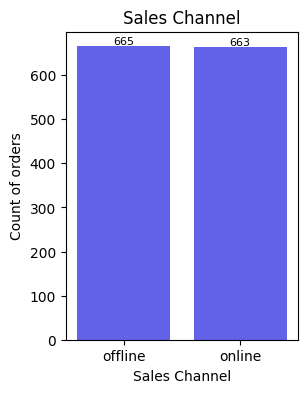

In [134]:
#count of orders
count_of_orders = full_df["Order ID"].count()
#create new column revenue
full_df["revenue"] = full_df["Units Sold"] * full_df["Unit Price"]
total_revenue = full_df["revenue"].sum()
#create new column total cost
full_df["total_cost"] = full_df["Unit Cost"] * full_df["Units Sold"]
total_cost = full_df["total_cost"].sum()
#count of country
total_of_country = full_df["name"].nunique()
#count of dold units
total_units_sold = full_df["Units Sold"].sum()

#create new column profit
full_df["profit"] = full_df["revenue"] - full_df["total_cost"]

#total sum of profit
total_profit = total_revenue - total_cost

#print all result
print(f"total number of orders: {count_of_orders}")
print(f"total revenue:${total_revenue}")
print(f"total cost of all products:${total_cost:.2f}")
print(f"total profit:${total_profit}")
print(f"total country that have orders: {total_of_country}")
print(f"Total units sold of products: {total_units_sold}")

#visualization sales channel statistic
channel_sales = full_df["Sales Channel"].str.lower().value_counts()

plt.figure(figsize=(3,4))
ax = sns.barplot(channel_sales, color = "blue", alpha = 0.7)
ax.bar_label(ax.containers[0], fontsize=8)
plt.title("Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Count of orders")

plt.show()


          item_type        revenue
8   Office Supplies 402,213,995.61
6         Household 294,205,199.23
4         Cosmetics 233,154,825.20
7              Meat 223,762,018.20
0         Baby Food 143,647,587.68
2            Cereal  95,791,404.50
11       Vegetables  89,746,728.64
10           Snacks  74,788,612.80
3           Clothes  64,626,552.80
9     Personal Care  45,579,022.94
1         Beverages  29,093,160.85
5            Fruits   5,520,299.76
----------------------------------
          item_type     total_cost
8   Office Supplies 324,236,819.36
6         Household 221,242,732.46
7              Meat 193,424,282.20
4         Cosmetics 140,431,519.03
0         Baby Food  89,706,590.52
2            Cereal  54,536,370.35
11       Vegetables  52,970,725.92
10           Snacks  47,761,190.40
9     Personal Care  31,603,612.26
3           Clothes  21,195,238.40
1         Beverages  19,491,498.07
5            Fruits   4,094,370.24
----------------------------------
          item_type 

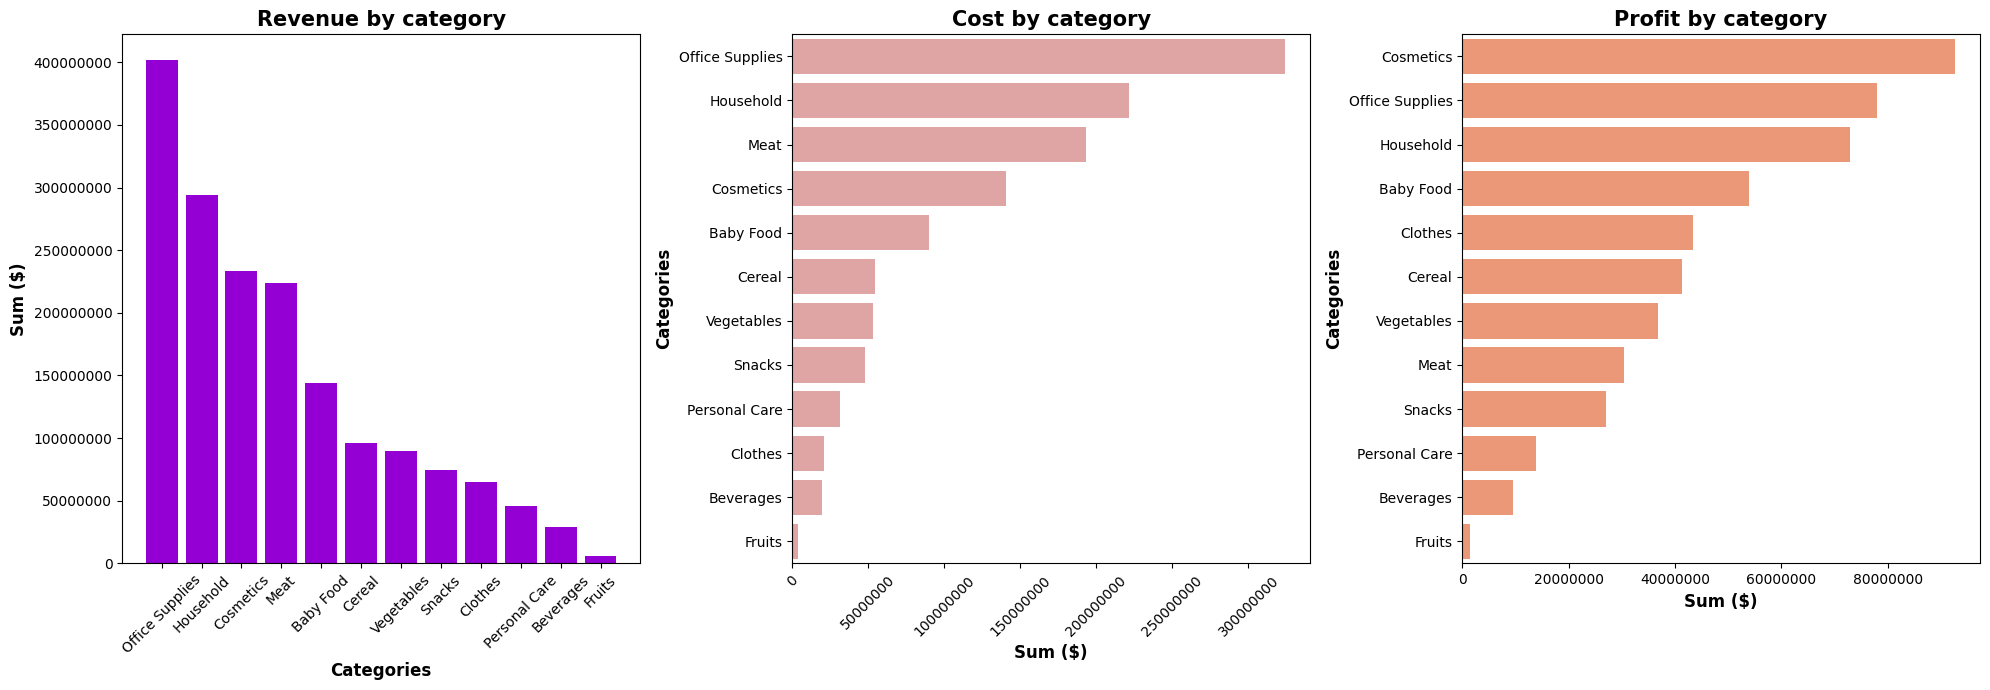

In [135]:
#revenue statistic by categories
pd.options.display.float_format = '{:,.2f}'.format

#revenue by item_type of products
revenue_by_category = full_df.groupby("item_type")["revenue"].sum().reset_index().sort_values(by="revenue", ascending = False)
print(revenue_by_category)
print("----------------------------------")
#cost by category
cost_by_categories = full_df.groupby("item_type")["total_cost"].sum().reset_index().sort_values(by="total_cost", ascending = False)
print(cost_by_categories)
print("----------------------------------")
#profit by category
profit_by_category = full_df.groupby("item_type")["profit"].sum().reset_index().sort_values(by = "profit", ascending = False)
print(profit_by_category)
print("----------------------------------")

#array graphics(revenue, cost, profit by categories)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].bar(revenue_by_category["item_type"], revenue_by_category["revenue"], color="darkviolet")
axes[0].set_title("Revenue by category", weight="bold", fontsize=15)
axes[0].set_xlabel("Categories", weight="bold", fontsize=12)
axes[0].set_ylabel("Sum ($)", weight="bold", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].ticklabel_format(style='plain', axis='y')

sns.barplot(data=cost_by_categories, x="total_cost", y='item_type', color="#db5856", alpha=0.6, ax=axes[1])
axes[1].set_title("Cost by category", weight="bold", fontsize=15)
axes[1].set_xlabel("Sum ($)", weight="bold", fontsize=12)
axes[1].set_ylabel("Categories", weight="bold", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].ticklabel_format(style='plain', axis='x')

sns.barplot(data=profit_by_category, x="profit", y="item_type", color="orangered",alpha=0.6, ax=axes[2])
axes[2].set_title("Profit by category", weight="bold", fontsize=15)
axes[2].set_xlabel("Sum ($)", weight="bold", fontsize=12)
axes[2].set_ylabel("Categories", weight="bold", fontsize=12)
axes[2].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()


          item_type        revenue     total_cost
0         Baby Food 143,647,587.68  89,706,590.52
1         Beverages  29,093,160.85  19,491,498.07
2            Cereal  95,791,404.50  54,536,370.35
3           Clothes  64,626,552.80  21,195,238.40
4         Cosmetics 233,154,825.20 140,431,519.03
5            Fruits   5,520,299.76   4,094,370.24
6         Household 294,205,199.23 221,242,732.46
7              Meat 223,762,018.20 193,424,282.20
8   Office Supplies 402,213,995.61 324,236,819.36
9     Personal Care  45,579,022.94  31,603,612.26
10           Snacks  74,788,612.80  47,761,190.40
11       Vegetables  89,746,728.64  52,970,725.92


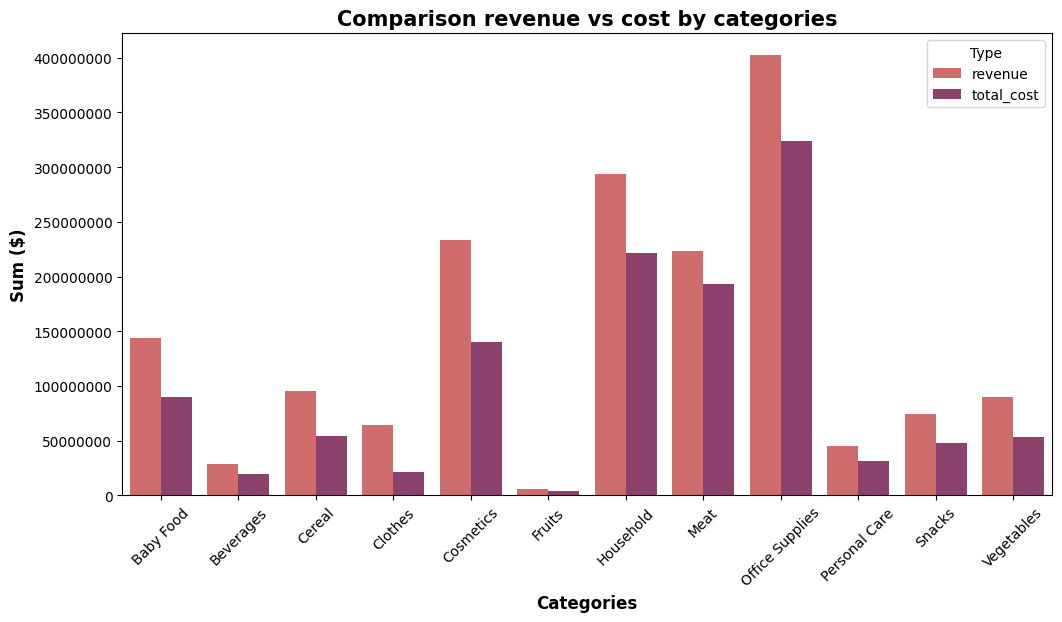

In [136]:
#Comparison between revenue and cost by categories
comparison_revenue_vs_cost = full_df.groupby("item_type")[["revenue", "total_cost"]].sum().reset_index()
print(comparison_revenue_vs_cost)
#used melt for make 1 column for sum and make column for type
df_melted = comparison_revenue_vs_cost.melt(
    id_vars="item_type",
    var_name="Type",
    value_name="Amount")

plt.figure(figsize=(12, 6))
sns.barplot(data = df_melted, x = "item_type", y = "Amount", hue = "Type", palette="flare")
plt.title("Comparison revenue vs cost by categories", style = "normal", weight = "bold", fontsize=15)
plt.ylabel("Sum ($)", style = "normal", weight = "bold", fontsize=12)
plt.xlabel("Categories", style = "normal", weight = "bold", fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

                      name        profit
1                  Andorra 15,410,036.63
43                 Ukraine 14,804,925.74
27                   Malta 14,610,127.88
36              San Marino 13,792,992.81
18                 Hungary 13,786,231.03
26               Macedonia 13,684,099.95
10          Czech Republic 13,635,593.78
35                  Russia 13,267,682.64
6   Bosnia and Herzegovina 13,257,602.77
17                  Greece 12,324,450.13
39                Slovenia 12,123,524.52
38                Slovakia 12,052,790.03
37                  Serbia 11,853,514.38
4                  Belarus 11,852,421.05
16                 Germany 11,582,919.10
33                Portugal 11,345,407.59
29              Montenegro 11,169,660.56
41                  Sweden 11,155,328.59
42             Switzerland 11,037,297.60
21                   Italy 10,913,921.97
14                  France 10,842,345.66
34                 Romania 10,793,548.69
22                  Latvia 10,759,285.29
32              

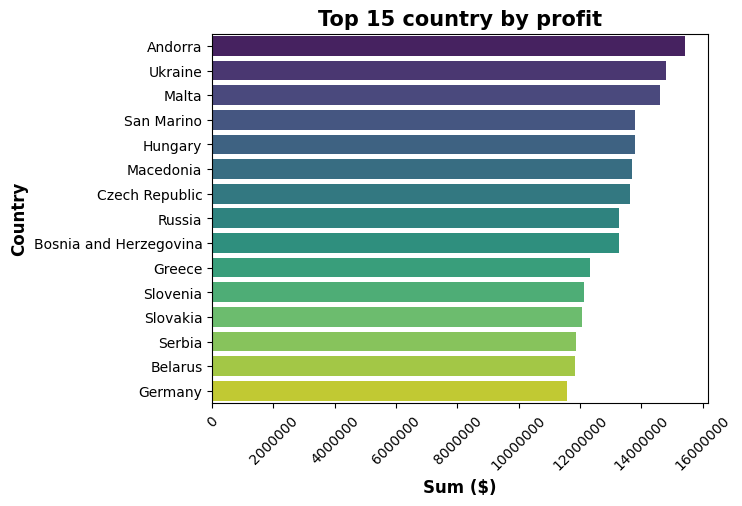

In [137]:
#Statistic by country
profit_by_country = full_df.groupby("name")["profit"].sum().reset_index().sort_values(by="profit", ascending=False)
print(profit_by_country)

top_15_countries = profit_by_country.head(15)

sns.barplot(data = top_15_countries, x = "profit", y = "name", palette = "viridis", hue = "name", legend = False)
plt.title("Top 15 country by profit", style = "normal", weight = "bold", fontsize=15)
plt.xlabel("Sum ($)", weight = "bold", fontsize=12)
plt.ylabel("Country", weight = "bold", fontsize=12)
plt.ticklabel_format(style="plain", axis = "x")
plt.xticks(rotation = 45)
plt.show()

    month_name        item_type       revenue
0      January        Baby Food 22,526,162.48
1      January        Beverages  1,188,337.80
2      January           Cereal  9,687,647.20
3      January          Clothes  8,985,766.56
4      January        Cosmetics 34,713,242.80
..         ...              ...           ...
139   December             Meat 32,597,752.74
140   December  Office Supplies 40,331,388.93
141   December    Personal Care  4,882,141.55
142   December           Snacks  3,580,442.28
143   December       Vegetables  7,299,516.86

[144 rows x 3 columns]


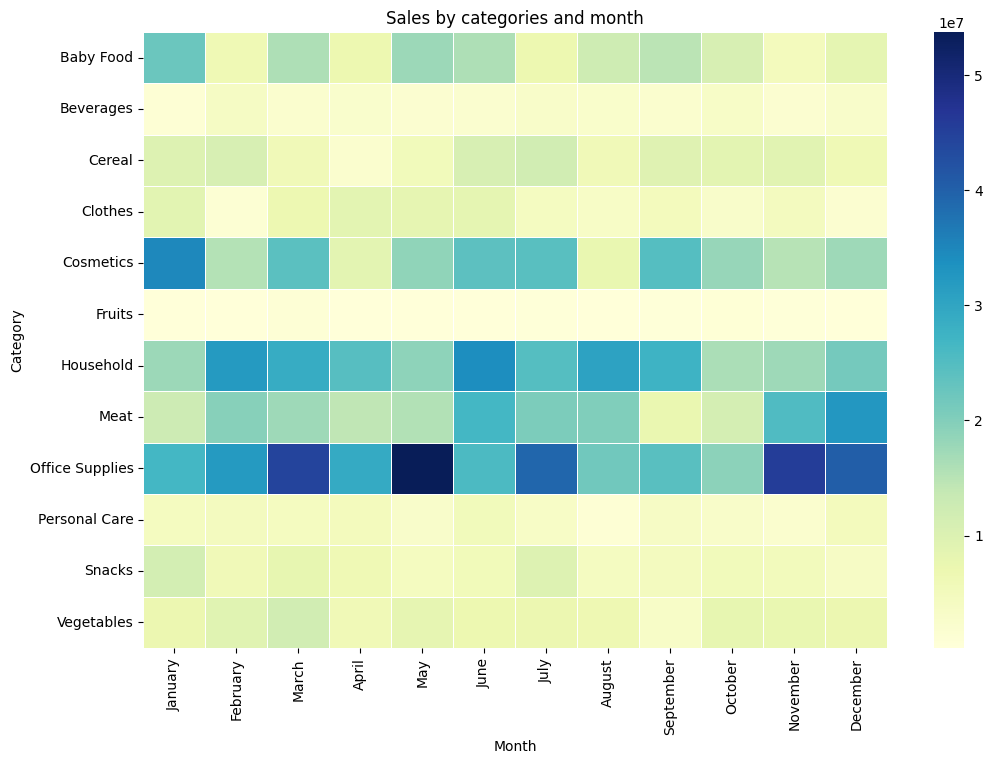

In [138]:
#visualiation by item_type of products and month
full_df["month_name"] = full_df["Order Date"].dt.month_name()

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
full_df["month_name"] = pd.Categorical(full_df["month_name"], categories=month_order, ordered=True)
sales_by_month_category = full_df.groupby(["month_name", "item_type"], observed=False)["revenue"].sum().reset_index()
print(sales_by_month_category)
heatmap_data_month = sales_by_month_category.pivot(index="item_type", columns="month_name", values="revenue")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_month, cmap="YlGnBu", annot=False, linewidths=.5)
plt.title("Sales by categories and month")
plt.xlabel("Month")
plt.ylabel("Category")
plt.show()

   Sales Channel month_name        profit
0        offline    January 23,381,075.35
1        offline   February 21,887,689.55
2        offline      March 29,186,443.72
3        offline      April 12,244,587.65
4        offline        May 23,514,924.55
5        offline       June 27,682,503.90
6        offline       July 20,545,292.65
7        offline     August 17,537,752.46
8        offline  September 21,459,671.49
9        offline    October 13,311,765.41
10       offline   November 20,568,098.88
11       offline   December 22,146,713.20
12        online    January 29,424,091.46
13        online   February 17,683,036.55
14        online      March 21,618,325.10
15        online      April 21,488,948.42
16        online        May 22,318,175.90
17        online       June 22,522,252.22
18        online       July 24,955,179.65
19        online     August 15,224,425.24
20        online  September 18,867,870.95
21        online    October 20,380,950.34
22        online   November 17,336

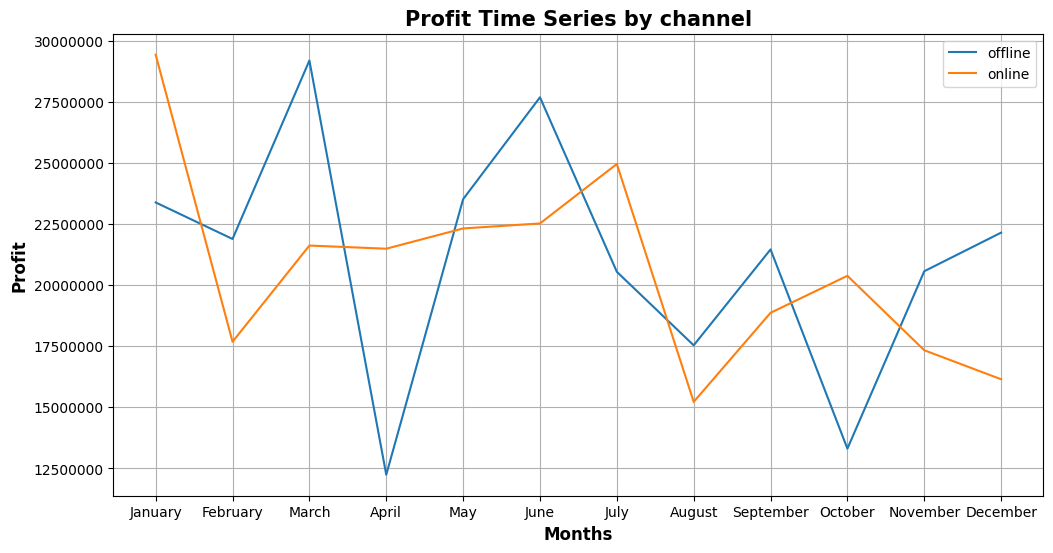

In [139]:
#profit of channels by years
full_df["Sales Channel"] = full_df["Sales Channel"].str.lower()
profit_by_channel = full_df.groupby(["Sales Channel", "month_name"], observed=False)["profit"].sum().reset_index()
print(profit_by_channel)

channels = profit_by_channel["Sales Channel"].unique()
plt.figure(figsize=(12, 6))
for channel in channels:
  channel_data = profit_by_channel[profit_by_channel["Sales Channel"] == channel]
  plt.plot(channel_data["month_name"], channel_data["profit"], label = channel)
plt.xlabel("Months", weight = "bold", fontsize=12)
plt.ylabel("Profit", style = "normal", weight = "bold", fontsize=12)
plt.title("Profit Time Series by channel", style = "normal", weight = "bold", fontsize=15)
plt.legend()
plt.grid(True)
plt.ticklabel_format(style="plain", axis = "y")
plt.show()

month
1    637,190.00
2    531,558.00
3    693,714.00
4    487,292.00
5    555,957.00
6    630,928.00
7    603,090.00
8    423,109.00
9    491,336.00
10   507,490.00
11   500,730.00
12   514,130.00
Name: Units Sold, dtype: float64


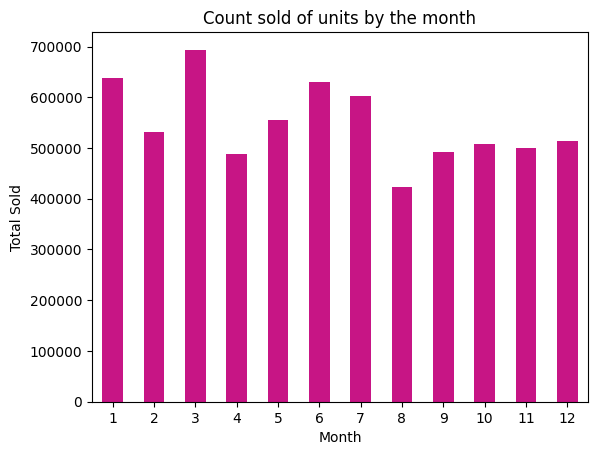

In [140]:
#sales units by the month and by the week
full_df["month"] = full_df["Order Date"].dt.month
full_df["day_of_week"] = full_df["Order Date"].dt.dayofweek
sold_units_by_month = full_df.groupby("month")["Units Sold"].sum()
print(sold_units_by_month)

sold_units_by_month.plot(kind="bar", xlabel = "Month", ylabel = "Total Sold", title = "Count sold of units by the month", color="mediumvioletred")
plt.xticks(rotation=0)
plt.show()

Monday      1,027,424.00
Tuesday       863,568.00
Wednesday     900,973.00
Thursday      850,351.00
Friday        866,387.00
Saturday    1,015,852.00
Sunday      1,051,969.00
Name: Units Sold, dtype: float64


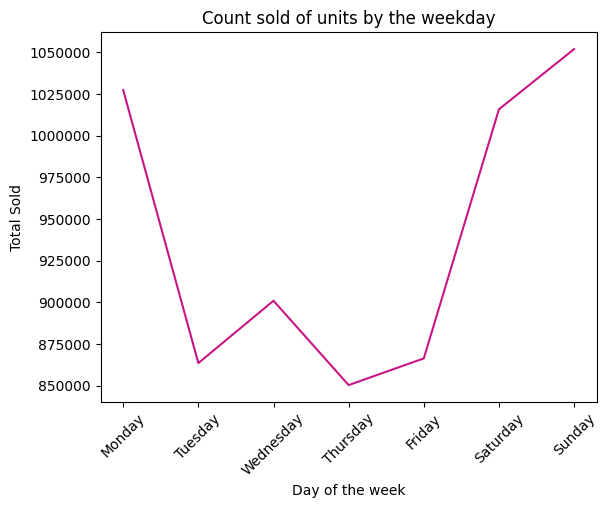

In [141]:
#Units sold by day of week
sold_units_by_the_week = full_df.groupby("day_of_week")["Units Sold"].sum()
#correct order day of week
sold_units_by_the_week.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
print(sold_units_by_the_week)
sold_units_by_the_week.plot(kind="line", xlabel = "Day of the week", ylabel = "Total Sold", title = "Count sold of units by the weekday", color="mediumvioletred")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis = "y")
plt.show()

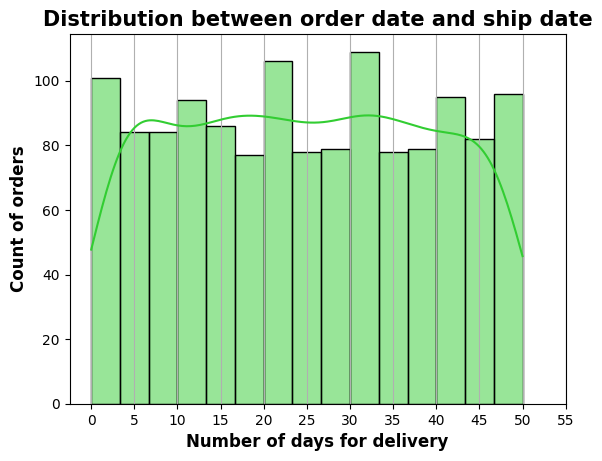

----------------------------------
Max days for delivery: 50
Min days for delivery: 0
Average days for delivery: 24.79
Median days for delivery: 25.0
Most common expresion: 32


In [142]:
#time to delivery order
full_df["delivery_time"] = (full_df["Ship Date"] - full_df["Order Date"]).dt.days

sns.histplot(data=full_df ,x = "delivery_time", kde = True, bins = 15, color = "limegreen")
plt.title("Distribution between order date and ship date", style = "normal", weight = "bold", fontsize=15)
plt.xlabel("Number of days for delivery", style = "normal", weight = "bold", fontsize=12)
plt.ylabel("Count of orders", style = "normal", weight = "bold", fontsize=12)
plt.grid(axis = "x")
plt.xticks(range(0,60,5))
plt.show()

print("----------------------------------")
#Calculated the most popular count of day for delivery
most_common_days = full_df["delivery_time"].mode()[0]
#print result all metrics
print(f"Max days for delivery: {full_df["delivery_time"].max()}\nMin days for delivery: {full_df["delivery_time"].min()}\nAverage days for delivery: {round(full_df["delivery_time"].mean(),2)}\nMedian days for delivery: {full_df["delivery_time"].median()}\nMost common expresion: {most_common_days}")

          item_type  delivery_time
9     Personal Care          20.76
3           Clothes          23.10
11       Vegetables          23.49
6         Household          23.94
1         Beverages          24.12
5            Fruits          24.42
10           Snacks          25.54
7              Meat          25.91
4         Cosmetics          25.91
0         Baby Food          26.34
8   Office Supplies          26.71
2            Cereal          27.18


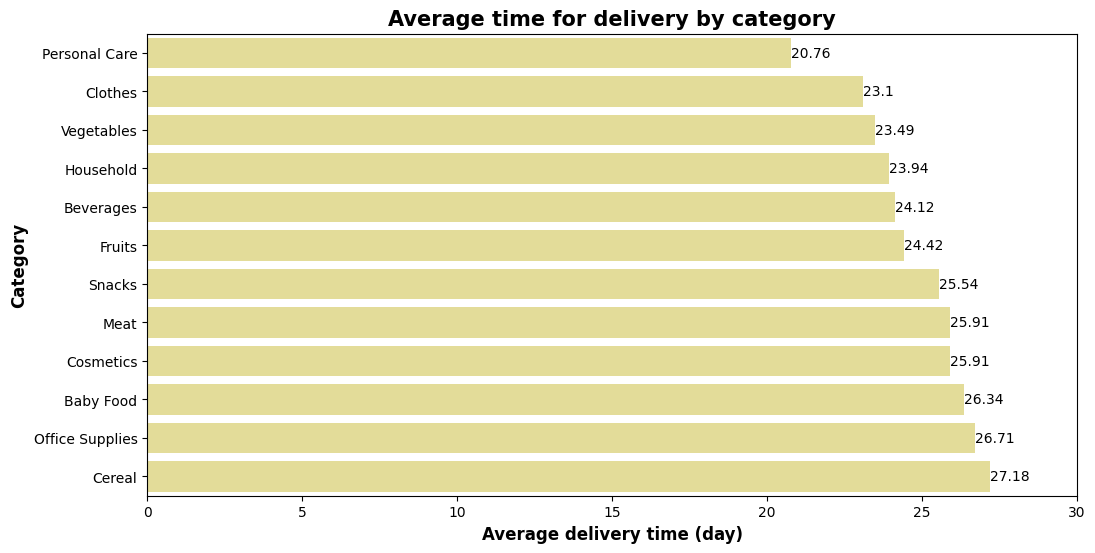

In [143]:
#visualization time delivery by category
delivery_by_category = round(full_df.groupby("item_type")["delivery_time"].mean().reset_index().sort_values(by="delivery_time", ascending = True),2)
print(delivery_by_category)
plt.figure(figsize=(12,6))
ax = sns.barplot(delivery_by_category, x = "delivery_time", y = "item_type", color = "khaki")
ax.bar_label(ax.containers[0], fontsize=10)
plt.title("Average time for delivery by category", style = "normal", weight = "bold", fontsize=15)
plt.xlabel("Average delivery time (day)", style = "normal", weight = "bold", fontsize=12)
plt.ylabel("Category", style = "normal", weight = "bold", fontsize=12)
plt.xticks(range(0,35,5))
plt.show()

                      name  delivery_time
18                 Hungary          32.64
15                 Georgia          29.70
3                  Austria          28.50
38                Slovakia          28.47
25              Luxembourg          27.75
24               Lithuania          27.56
32                  Poland          27.46
35                  Russia          27.38
28                  Monaco          26.85
7                 Bulgaria          26.80
29              Montenegro          26.68
30             Netherlands          26.62
5                  Belgium          26.54
40                   Spain          26.44
14                  France          26.42
1                  Andorra          26.27
13                 Finland          26.22
0                  Albania          26.19
2                  Armenia          26.17
6   Bosnia and Herzegovina          26.06
43                 Ukraine          25.76
4                  Belarus          25.25
10          Czech Republic        

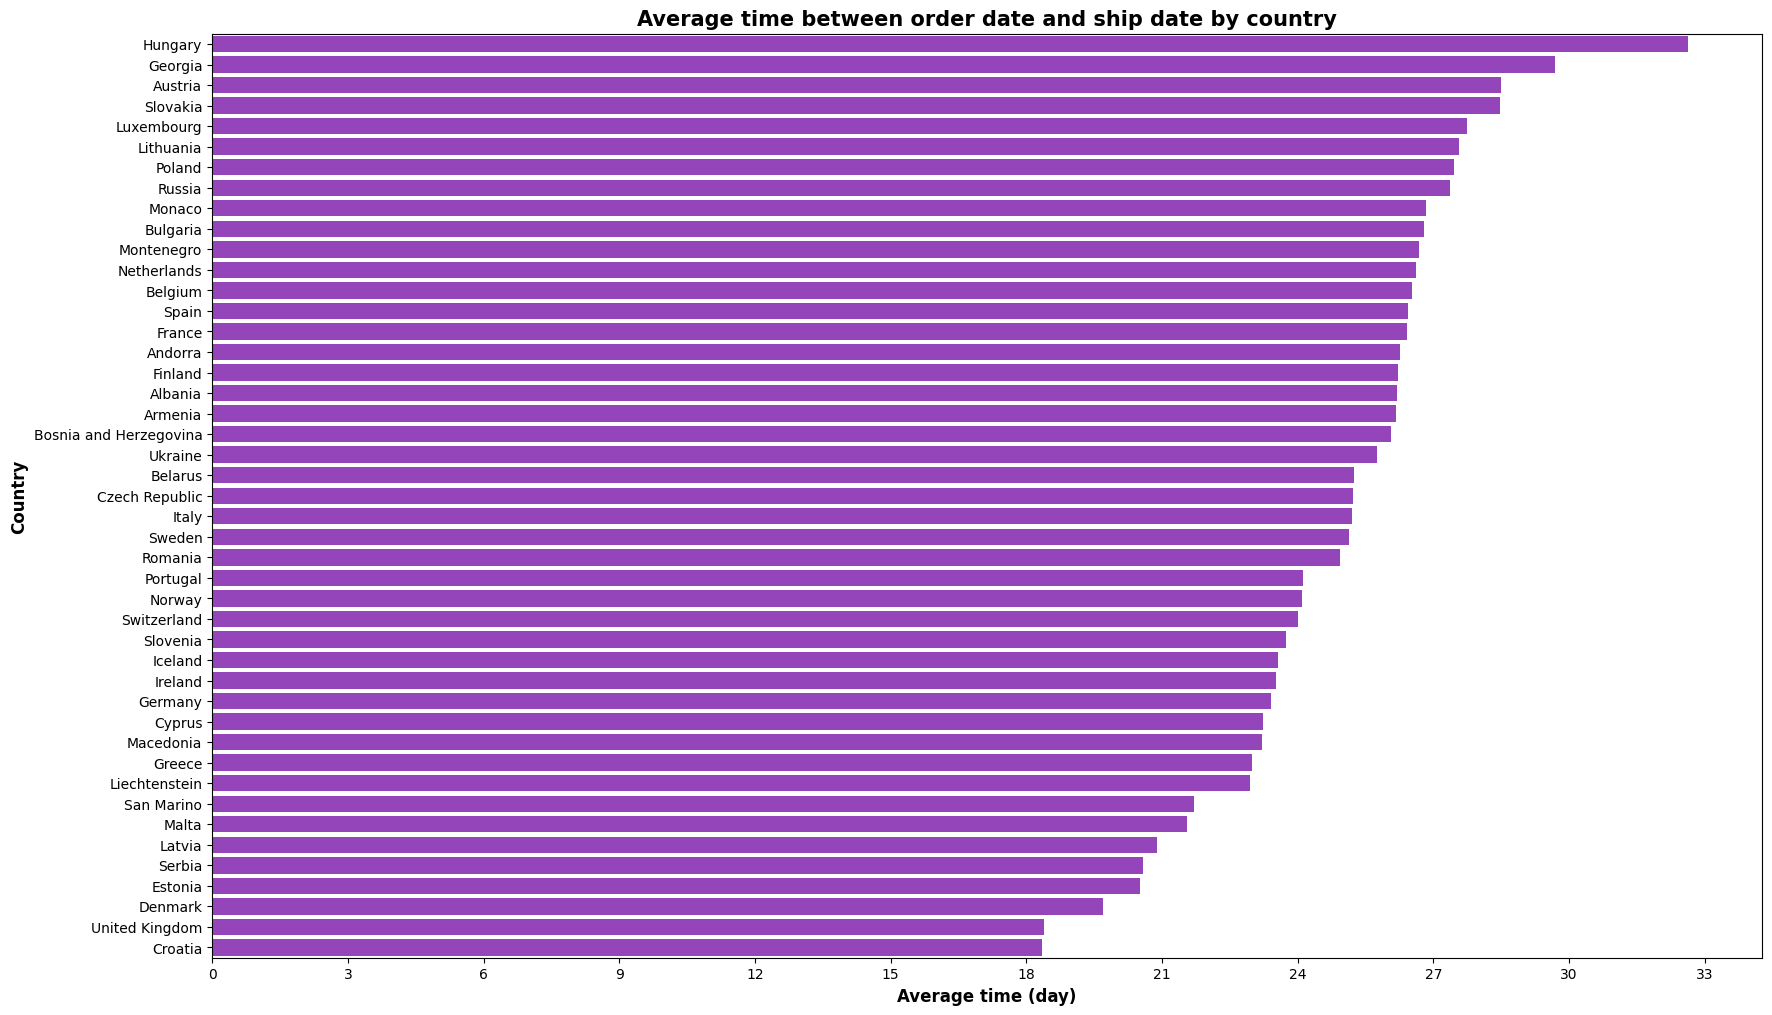

In [144]:
#visualization time delivery by country
country_delivery_time = full_df.groupby("name")["delivery_time"].mean().reset_index().sort_values(by = "delivery_time", ascending = False)

print(country_delivery_time)
plt.figure(figsize=(20,12))
sns.barplot(data = country_delivery_time, x = 'delivery_time', y = 'name', color = "darkorchid")
plt.title("Average time between order date and ship date by country", style = "normal", weight = "bold", fontsize=15)
plt.xlabel("Average time (day)", style = "normal", weight = "bold", fontsize=12)
plt.ylabel("Country", style = "normal", weight = "bold", fontsize=12)
plt.xticks(range(0,34,3))
plt.show()

    region  year  delivery_time
2     Asia  2012          30.73
1     Asia  2011          30.00
4     Asia  2014          28.33
6     Asia  2016          26.62
9   Europe  2011          26.19
14  Europe  2016          25.89
11  Europe  2013          25.48
5     Asia  2015          25.45
10  Europe  2012          24.69
13  Europe  2015          24.56
8   Europe  2010          24.28
3     Asia  2013          24.00
12  Europe  2014          23.51
15  Europe  2017          23.13
7     Asia  2017          23.00
0     Asia  2010          18.00


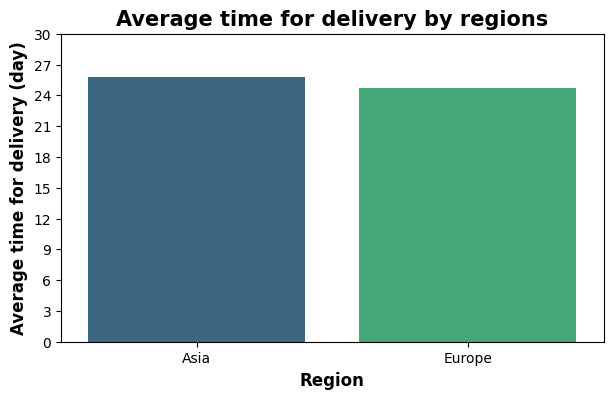

In [145]:
#create column with years
full_df["year"] = full_df["Order Date"].dt.year


#visualization delivery time by years and regions
region_delivery_time = full_df.groupby(["region","year"])["delivery_time"].mean().reset_index().sort_values(by = "delivery_time", ascending = False)
print(region_delivery_time)
plt.figure(figsize=(7,4))
sns.barplot(region_delivery_time, x = "region", y = "delivery_time", errorbar = None, hue = "region", palette = "viridis")
plt.xlabel("Region",style = "normal", weight = "bold", fontsize=12)
plt.ylabel("Average time for delivery (day)", style = "normal", weight = "bold", fontsize=12)
plt.title("Average time for delivery by regions", style = "normal", weight = "bold", fontsize=15)
y_ticks = np.arange(0, plt.gca().get_ylim()[1] + 5, 3)
plt.yticks(y_ticks)
plt.show()


45


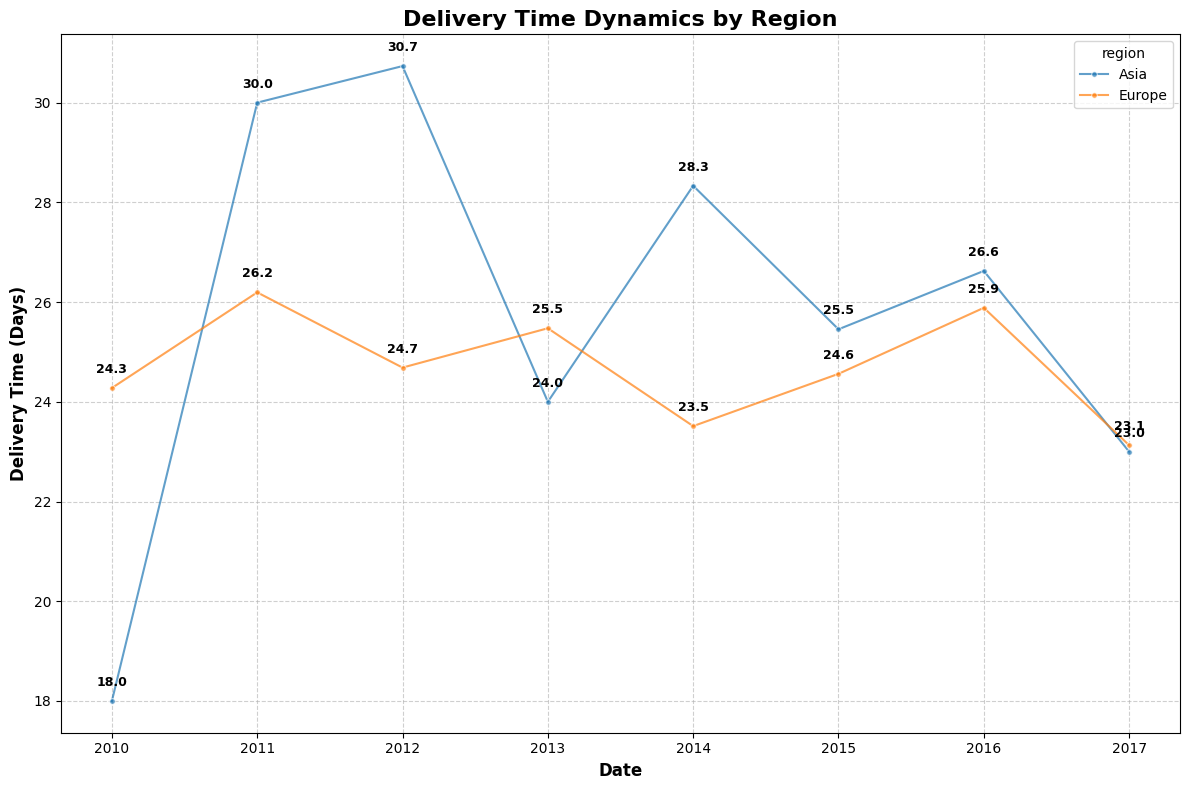

In [146]:
#count of country that did orders by region
list_of_country = full_df.groupby("name")["region"].unique().count()
print(list_of_country)
#delivery time by years and regions
plt.figure(figsize=(12, 8))
ax = sns.lineplot(data=region_delivery_time, x="year", y="delivery_time", hue="region", palette="tab10", marker="o",markersize=4,alpha=0.7)
plt.title("Delivery Time Dynamics by Region", fontsize=16, weight="bold")
plt.xlabel("Date", fontsize=12, weight="bold")
plt.ylabel("Delivery Time (Days)", fontsize=12, weight="bold")
plt.grid(True, linestyle='--', alpha=0.6)
#signatures for points on charts
for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    for x, y in zip(x_data, y_data):
        ax.text(
            x, y + 0.3,
            f'{y:.1f}',
            horizontalalignment='center',
            fontsize=9,
            color='black',
            weight='bold'
        )
plt.tight_layout()
plt.show()

##**Visualisation of profit dependence on delivery days**

**In my opinion, profit is not distributed according to delivery time, because we see an almost symmetrical situation between delivery times of up to 25 days and delivery times of more than 25 days on the graph, but there is still some difference.**

**In the histogram, we see that the number of orders is divided into two groups, with orders that took less than 25 days having an advantage of 40 orders. But in the next graph, we see a different situation, where the group with a delivery time of 25+ days has a higher profit (13 million) than the first group. Next, I listed the top 15 highest profits and found that 9 values belong to the group (25>).**
> **I think there is a certain correlation, but it is most likely related to the number of items ordered, because, as the analysis shows, orders that take longer to deliver have a larger number of items, which increases the price, but this connection is not strong enough to say that there is a correlation between profit and delivery time.**





    delivery_time        profit  orders_count
0               0  6,967,594.12            20
1               1  6,809,916.94            22
2               2  8,830,276.81            26
3               3  9,412,351.70            33
4               4  9,319,976.51            31
5               5 11,276,412.01            27
6               6  9,517,301.39            26
7               7 12,822,986.01            32
8               8  8,278,980.87            24
9               9 11,879,950.09            28
10             10  3,397,577.40            16
11             11 11,057,028.66            27
12             12 11,562,784.89            31
13             13  6,296,961.45            20
14             14  7,371,059.48            24
15             15  8,263,645.40            29
16             16 14,372,732.34            33
17             17 12,285,558.66            28
18             18  5,123,042.88            17
19             19 14,305,161.52            32
20             20  6,816,365.43   

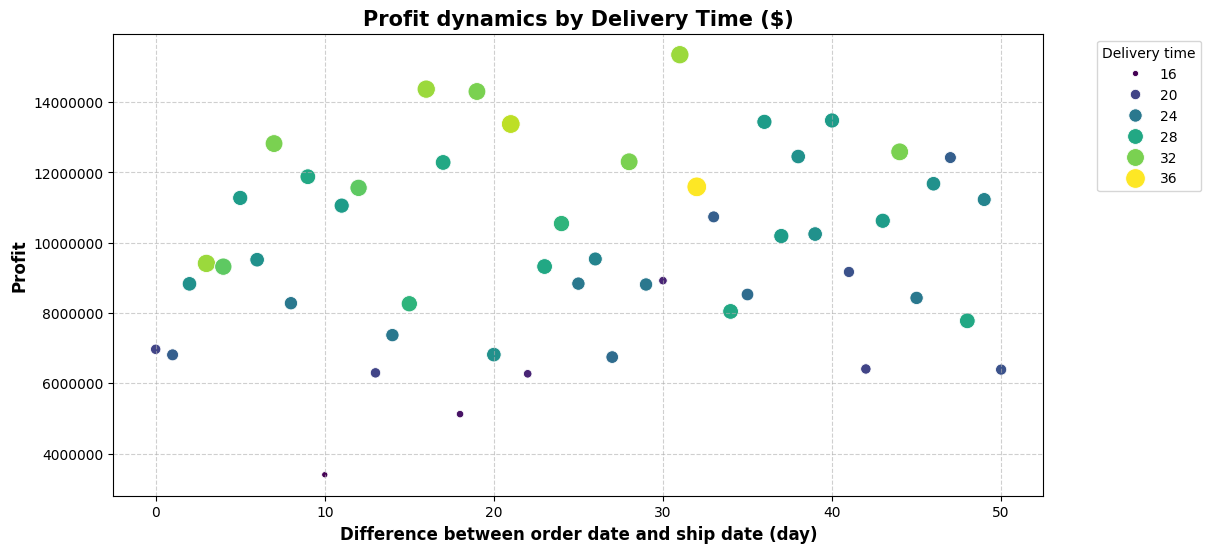

In [147]:
profit_by_delivery_time = full_df.groupby("delivery_time").agg({"profit": "sum", "Order Date": "count"}).rename(columns={"Order Date": "orders_count"}).reset_index()
print(profit_by_delivery_time)

#scatter plot of profit dynamics by delivery times
plt.figure(figsize=(12,6))
sns.scatterplot(data = profit_by_delivery_time, x = "delivery_time", y = "profit",hue = "orders_count", size = "orders_count",palette="viridis", sizes=(20, 200))
plt.title("Profit dynamics by Delivery Time ($)", fontsize=15, weight="bold")
plt.xlabel("Difference between order date and ship date (day)", fontsize=12, weight="bold")
plt.ylabel("Profit", fontsize=12, weight="bold")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Delivery time", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ticklabel_format(style="plain", axis = "y")
plt.show()


----------------------------------
Profit with delivery time (<=25)   244,323,777.43
Profit with delivery time (>25)    257,110,681.57
Name: profit, dtype: float64
----------------------------------
Orders with delivery time (<=25)    685
Orders with delivery time (>25)     643
Name: Order Date, dtype: int64


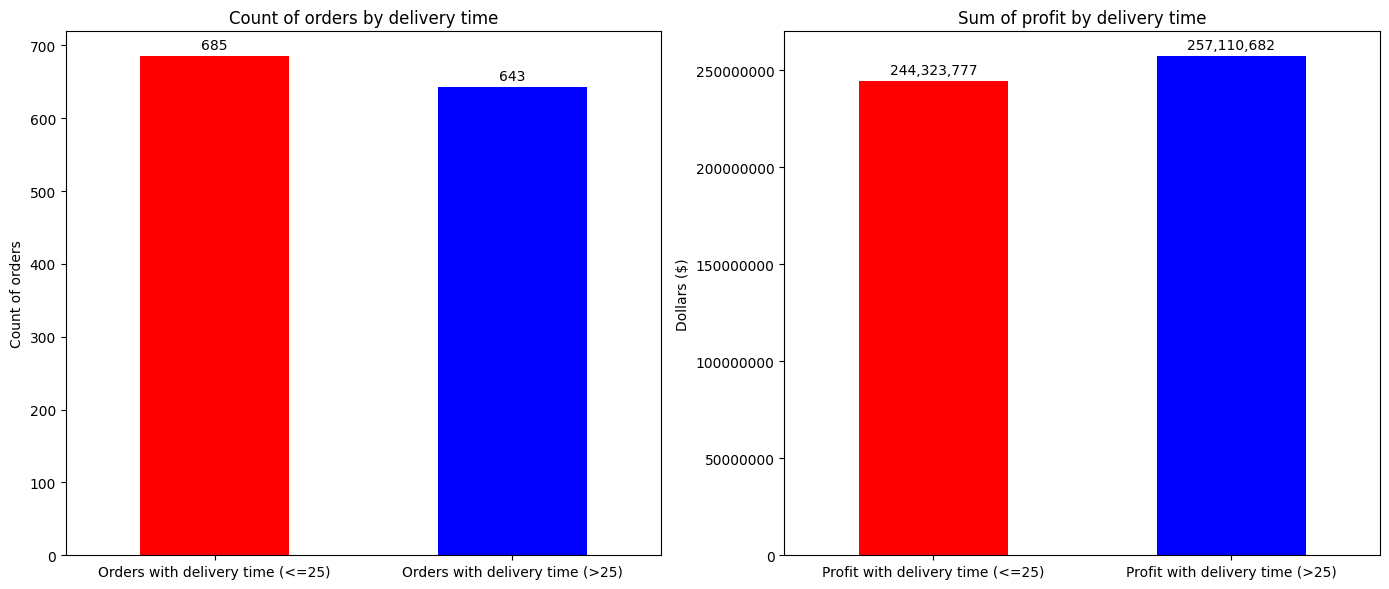

In [148]:
#calucated count of orders and sum of profit by delivery time
orders_split_by_delivery_time = full_df.groupby(np.where(full_df["delivery_time"] > 25, "Orders with delivery time (>25)","Orders with delivery time (<=25)"))["Order Date"].count()
profit_split_by_delivery_time = full_df.groupby(np.where(full_df["delivery_time"] > 25, "Profit with delivery time (>25)", "Profit with delivery time (<=25)")
)["profit"].sum()
print("----------------------------------")
print(profit_split_by_delivery_time)
print("----------------------------------")
print(orders_split_by_delivery_time)

#visualization result
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Chart 1 count of orders
orders_split_by_delivery_time.plot(kind='bar', ax=axes[0], color=['red', 'blue'], rot=0)
axes[0].set_title("Count of orders by delivery time")
axes[0].set_ylabel("Count of orders")
axes[0].bar_label(axes[0].containers[0], padding=3)
plt.tight_layout()
# Chart 2 sum of profit
profit_split_by_delivery_time.plot(kind='bar', ax=axes[1], color=['red', 'blue'], rot=0)
axes[1].set_title("Sum of profit by delivery time")
axes[1].set_ylabel("Dollars ($)")
plt.ticklabel_format(style="plain", axis = "y")
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=3)
plt.tight_layout()
plt.show()

##**Visualization sales of time by categories, countries and regions**
###**Main tendency**:
- *In the three charts, we have highlighted four years (2011-2012, 2014-2015) as some of the most successful*
- *2013 and 2017 were the worst year for all charts*
- *European countries and regions completely dominated in sales*
- *Office supplies, cosmetics, household goods, and meat were the most popular categories throughout the entire existence of the store and these categories. Other categories failed to exceed 20 million sales in the entire history of the store, and only ‘baby food’ exceeded 20 million sales in two years.*
- *Andorra and Ukraine are ranked first and second among all countries in terms of profit, but they have rather mediocre sales figures and only exceeded 10 million in one year.*

###**Conclusion:**

**In recent years, we have seen negative sales dynamics in Europe and Asia, with the same trend observed across all categories, and a 30% drop in sales in the four leading categories.**

**I believe that the store needs to open up a new continent and new countries for sales and start actively advertising its products.**

**I can assume that during the store's operation, other stores selling the same products and goods have also opened, which has also had a significant impact on sales. Also, don't forget about inflation and rising product prices.**

Combined this all reasons we have:
- *Gradual decline in sales*
- *Loss of the majority of customers*
- *Decline in profits and increase in expenses*

    region  year        revenue
0     Asia  2010  14,040,364.13
1     Asia  2011   4,347,439.86
2     Asia  2012  21,790,920.12
3     Asia  2013  12,331,488.07
4     Asia  2014  12,276,568.25
5     Asia  2015  14,766,917.42
6     Asia  2016   6,243,819.98
7     Asia  2017   7,533,369.54
8   Europe  2010 188,214,068.09
9   Europe  2011 209,864,906.73
10  Europe  2012 245,769,462.75
11  Europe  2013 163,024,640.21
12  Europe  2014 204,698,038.71
13  Europe  2015 199,220,094.77
14  Europe  2016 175,034,269.87
15  Europe  2017 119,827,392.76


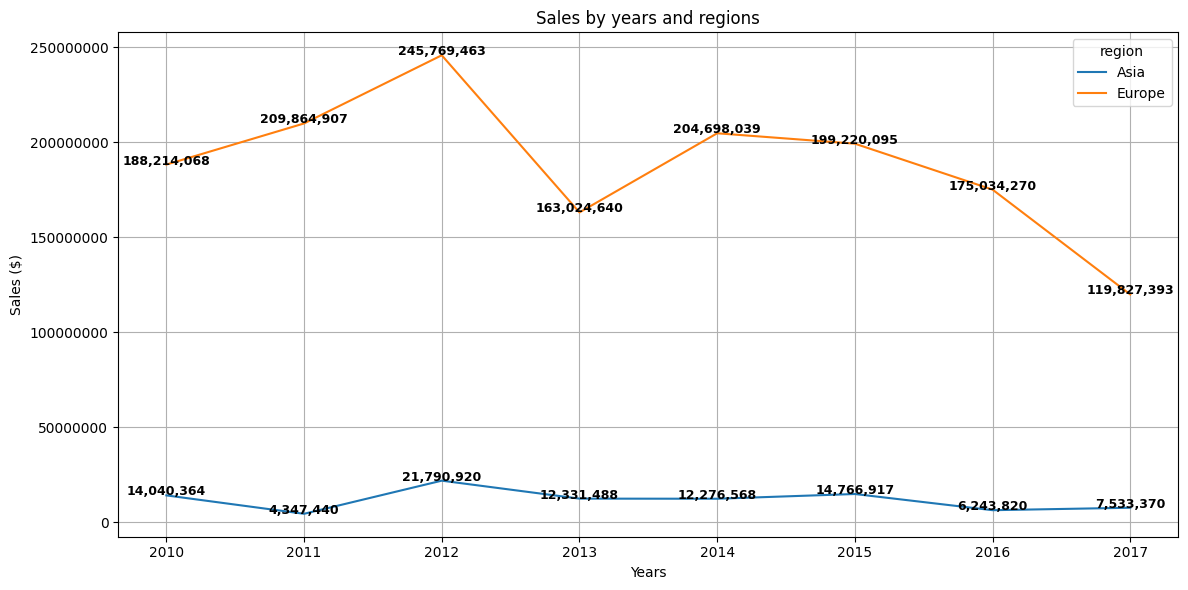

In [149]:
#sales by regions and years
sales_by_region = full_df.groupby(["region", "year"])["revenue"].sum().reset_index()
print(sales_by_region)
plt.figure(figsize=(12,6))
ax  = sns.lineplot(data = sales_by_region, x = "year", y = "revenue", hue = "region")
plt.title("Sales by years and regions")
plt.xlabel("Years")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.ticklabel_format(style = "plain", axis = "y")
#signature for points
for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    for x, y in zip(x_data, y_data):
        ax.text(
            x, y + 1,
            f'{y:,.0f}',
            horizontalalignment='center',
            fontsize=9,
            color='black',
            weight='bold'
        )
plt.tight_layout()
plt.show()

    region  year      revenue
0     Asia  2010 1,276,396.74
1     Asia  2011   483,048.87
2     Asia  2012 1,452,728.01
3     Asia  2013 1,370,165.34
4     Asia  2014 1,023,047.35
5     Asia  2015 1,342,447.04
6     Asia  2016   780,477.50
7     Asia  2017 1,076,195.65
8   Europe  2010 1,271,716.68
9   Europe  2011 1,362,759.13
10  Europe  2012 1,428,892.23
11  Europe  2013 1,156,203.12
12  Europe  2014 1,279,362.74
13  Europe  2015 1,433,238.09
14  Europe  2016 1,114,867.96
15  Europe  2017 1,288,466.59


<Figure size 1200x600 with 0 Axes>

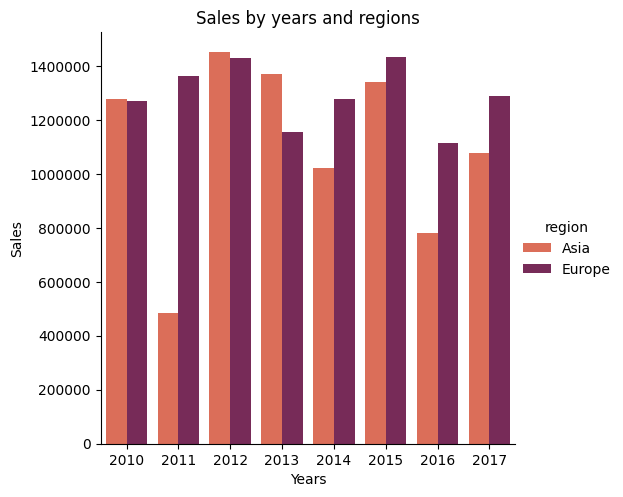

In [150]:
#Average values of revenue by regions and years
sales_by_region_mean = full_df.groupby(["region", "year"])["revenue"].mean().reset_index()
print(sales_by_region_mean)
plt.figure(figsize=(12,6))
sns.catplot(x = "year", y = "revenue",hue = "region", kind = "bar", data = sales_by_region_mean,errorbar = ("ci", False), palette = "rocket_r")
plt.xlabel("Years")
plt.ylabel("Sales")
plt.title("Sales by years and regions")
plt.ticklabel_format(style = "plain", axis = "y")
plt.show()

          item_type  year       revenue
69  Office Supplies  2015 75,447,888.18
65  Office Supplies  2011 58,527,498.75
34        Cosmetics  2012 56,664,180.40
68  Office Supplies  2014 56,529,586.47
66  Office Supplies  2012 52,324,072.29
..              ...   ...           ...
40           Fruits  2010    701,634.66
44           Fruits  2014    694,179.99
45           Fruits  2015    563,289.42
42           Fruits  2012    524,168.73
47           Fruits  2017    384,414.66

[96 rows x 3 columns]


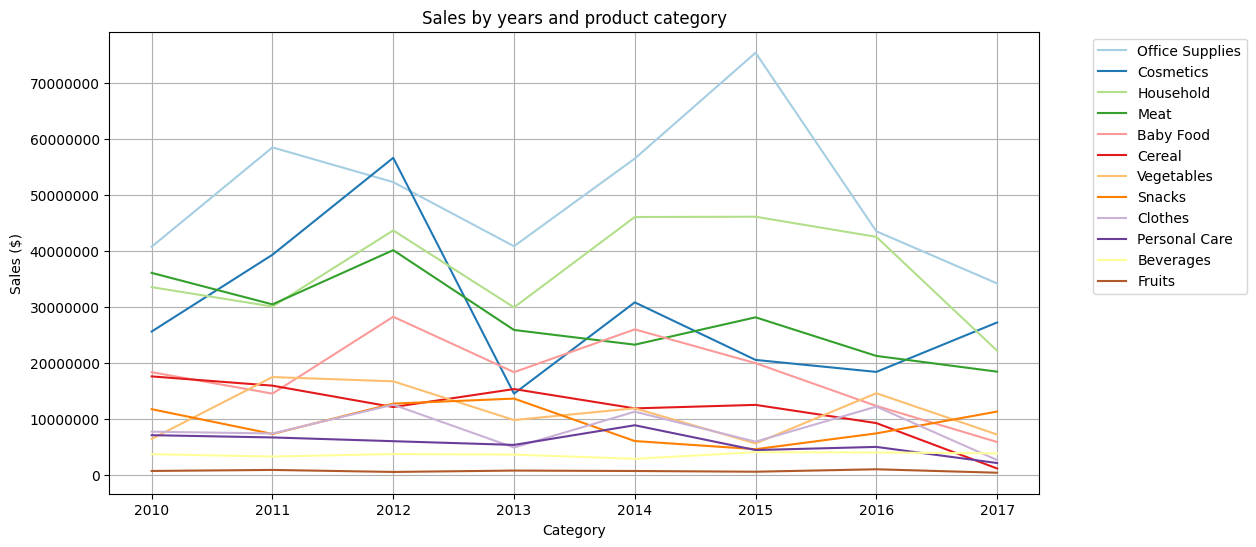

In [151]:
#revenue by item_type and year
sales_by_category = full_df.groupby(["item_type", "year"])["revenue"].sum().reset_index().sort_values(by="revenue", ascending = False)
print(sales_by_category)

plt.figure(figsize=(12,6))
sns.lineplot(sales_by_category, x = "year", y = "revenue", hue = "item_type", palette = "Paired")
plt.title("Sales by years and product category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.ticklabel_format(style = "plain", axis = "y")
plt.show()


name
Czech Republic           53,543,932.14
Ukraine                  53,252,317.54
Bosnia and Herzegovina   50,117,508.49
Macedonia                49,222,085.25
San Marino               47,883,708.48
Name: revenue, dtype: float64


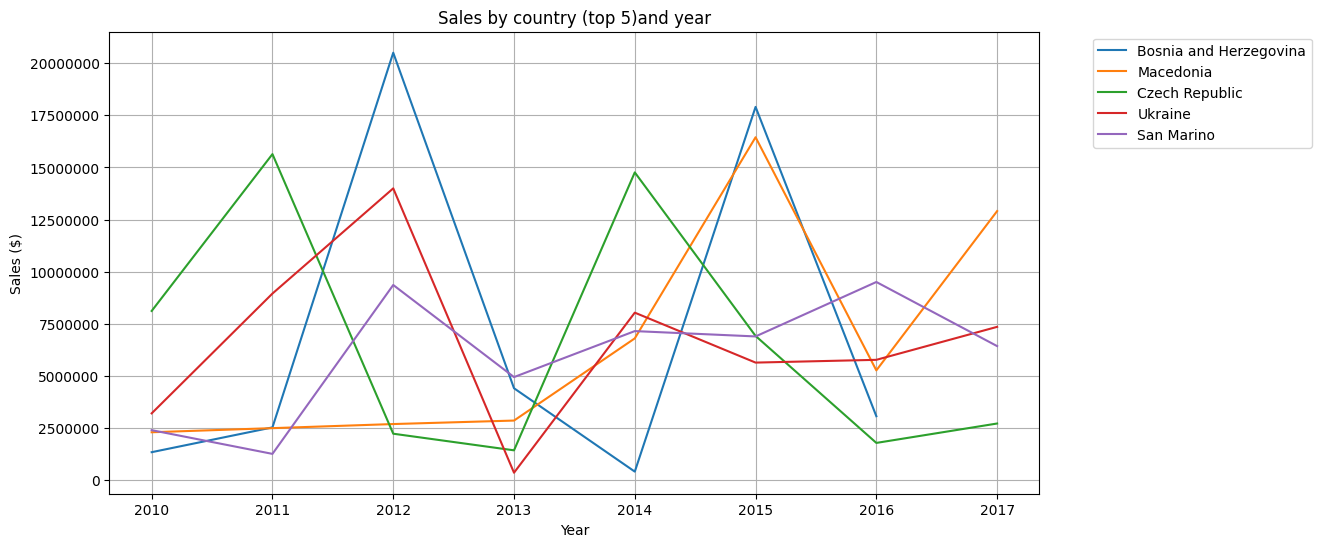

In [152]:
#top 5 countries by years and sales
sales_by_country = full_df.groupby(["name", "year"])["revenue"].sum().reset_index().sort_values(by = "revenue", ascending = False)
#filtred top 5 countries by revenue that used on charts
top_5_countries = full_df.groupby("name")["revenue"].sum().sort_values(ascending=False).head(5).index
#top 5 countries by revenue fro all time
top_5_country_by_revenue = full_df.groupby("name")["revenue"].sum().sort_values(ascending = False).nlargest(5)
print(top_5_country_by_revenue)

filtered_top5 = sales_by_country[sales_by_country["name"].isin(top_5_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(filtered_top5, x = "year", y = "revenue", hue = "name")
plt.title("Sales by country (top 5)and year")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style = "plain", axis = "y")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##**Analysis sales for days of week and months**

*I don't see any patterns in the sales of different types of goods. We can see four categories that sell well every day of the week and month. Other categories show no patterns and sold without significant changes for all time.*

  day_of_week        revenue
0      Monday 275,468,475.80
1     Tuesday 213,523,894.55
2   Wednesday 261,215,696.73
3    Thursday 214,922,230.51
4      Friday 263,807,003.93
5    Saturday 233,641,145.43
6      Sunday 239,550,961.26


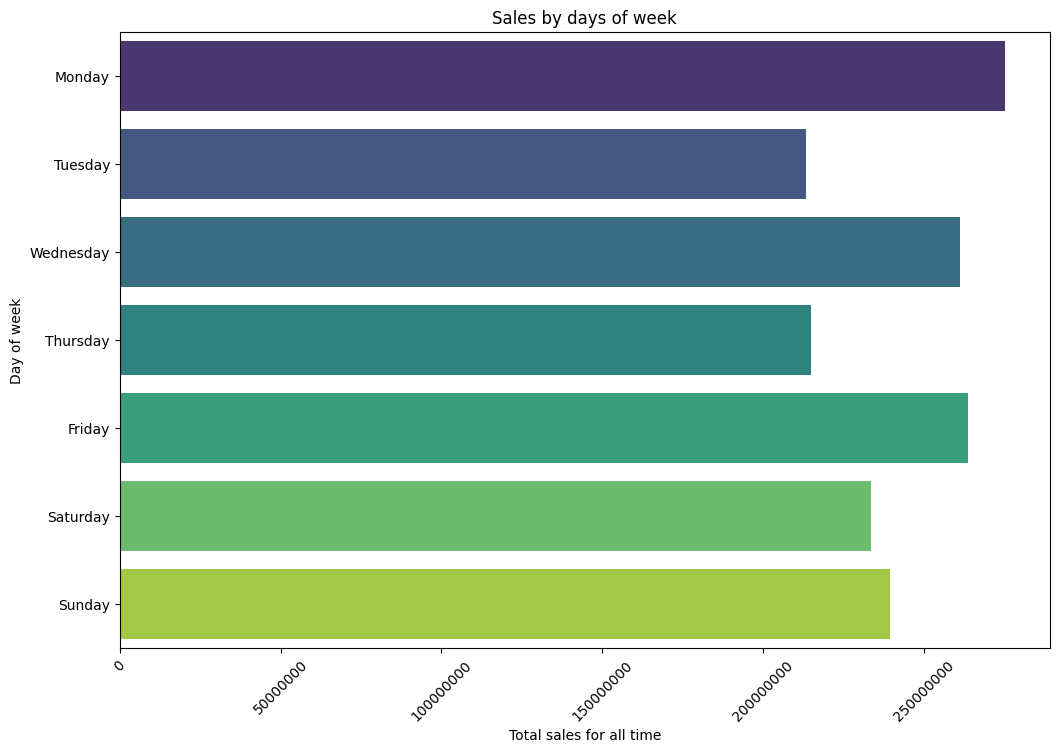

In [153]:
#sales by weekdays
full_df["day_of_week"] = full_df["Order Date"].dt.day_name()

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
full_df["day_of_week"] = pd.Categorical(full_df["day_of_week"], categories=days_order, ordered=True)

sales_by_day = full_df.groupby("day_of_week", observed=False)["revenue"].sum().reset_index()
print(sales_by_day)

plt.figure(figsize=(12, 8))
sns.barplot(sales_by_day, x = "revenue", y = "day_of_week", hue = "day_of_week", palette = "viridis")
plt.title("Sales by days of week")
plt.xlabel("Total sales for all time")
plt.ylabel("Day of week")
plt.ticklabel_format(style = "plain", axis = "x")
plt.xticks(rotation = 45)
plt.show()

   day_of_week        item_type       revenue
0       Monday        Baby Food 15,600,926.64
1       Monday        Beverages  4,845,736.35
2       Monday           Cereal  8,572,341.80
3       Monday          Clothes  7,442,951.52
4       Monday        Cosmetics 24,434,233.60
..         ...              ...           ...
79      Sunday             Meat 23,433,036.27
80      Sunday  Office Supplies 66,650,692.29
81      Sunday    Personal Care  6,852,243.20
82      Sunday           Snacks 11,298,091.26
83      Sunday       Vegetables 17,562,685.94

[84 rows x 3 columns]


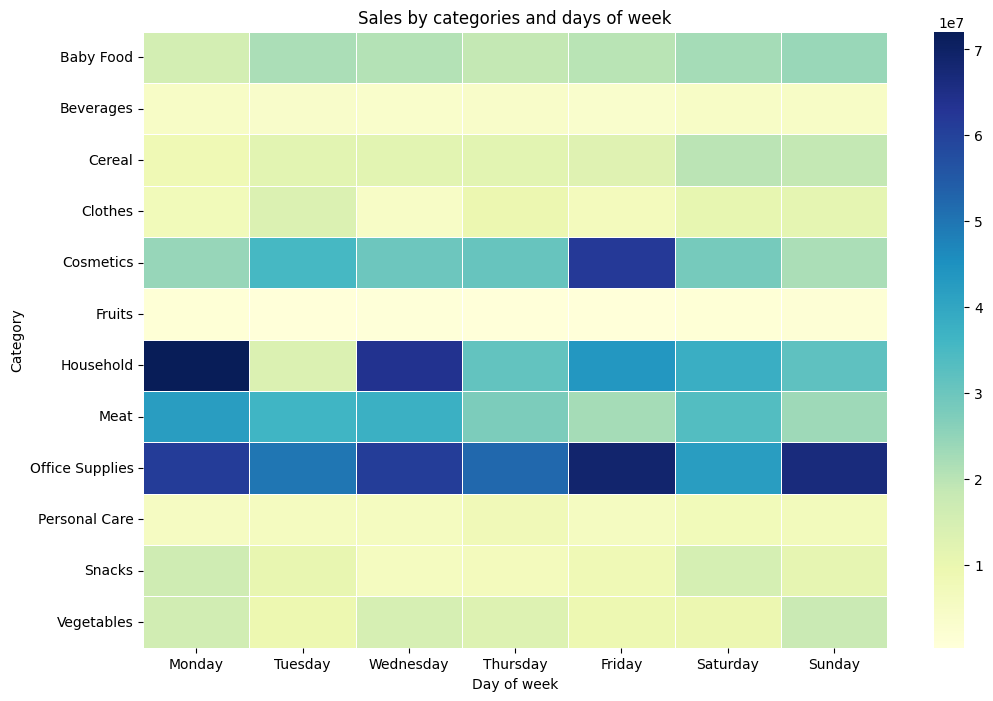

In [154]:
#visualization sales by category and day of week
sales_by_day_of_week = full_df.groupby(["day_of_week","item_type"], observed=False)["revenue"].sum().reset_index()
print(sales_by_day_of_week)
heatmap_data = sales_by_day_of_week.pivot(index="item_type", columns="day_of_week", values="revenue")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, linewidths=.5)
plt.title("Sales by categories and days of week")
plt.xlabel("Day of week")
plt.ylabel("Category")
plt.show()


##**Recomendation and overall conclusions**

1. I recommend that the store expand its area of influence and sales. Currently, the store has customers from two regions and generates millions in profits, which can be increased by attracting new customers. In my opinion, this should be done right now, at a time when sales in our main regions are declining.
2. The company has four main categories of goods that generate the store's main profit. Currently, the store is experiencing negative dynamics in almost all categories, and in this situation, I recommend focusing on the main ones (stationery, cosmetics, household goods, and meat). They are still the leaders in terms of total profits, and with additional attention, the store will be able to start increasing its profits.
3. In total, orders were placed in the store from 45 countries, including 42 countries in Europe and only 3 in Asia, but on average over one year, almost all results were similar, and in 2010, 2012, and 2013, Asia had higher sales than Europe, on average per order. **Perhaps the store should consider further development in the Asian region given these figures?**
4. Most of the customers are located in Europe, as can be seen in the graphs in this document, and I believe that the store should first and foremost reduce delivery times for Europe, since for a company with such sales volumes, delivery times for European countries are too long:
- **Average days for delivery: 24.79**
- **Median days for delivery: 25.0**
- **Most common expresion: 32**
5. When I was compiling sales charts by day of the week, I noticed that the largest number of goods are sold on weekends, and this mass sales trend also extends to Mondays.  In this case, I would advise the company to introduce promotions and discounts to further encourage customers to buy their products, and to leave the weekdays as they are.

- **Monday      1,027,424.00**
- Tuesday       863,568.00
- Wednesday     900,973.00
- Thursday      850,351.00
- Friday        866,387.00
- **Saturday    1,015,852.00**
- **Sunday      1,051,969.00**
6. I am saying that it is necessary to focus on the most important product categories, but the store should also pay attention to product categories that generate almost no profit, such as fruit and beverages. The store spends almost the same amount on purchases as it earns, so in my opinion, this money should be invested in other categories.
